# Simulation: run-mean removal, voxel centring & the across-session correlation

A sandbox to test, on data with a **known** ground truth, the questions that came up around
`scripts/correlation.py` and `scripts/geometry_dataframe.py`:

1. **Does `X=indicator(part_vec)` (run-mean removal) do anything?** It depends on the metric:
   - *crossnobis distance* (`G_to_dist`): invariant **within** a session, but **not** across sessions.
   - *cosine / correlation* (`G_to_cosine`): always changes — it removes the common activation that inflates cosine toward 1.
2. **Is voxel-mean centring (`data - data.mean(axis=1)`) the same thing?** No — it's a different operation.
3. **Matched (diagonal) vs mismatched (off-diagonal) extraction.** `correlation.py` reads the diagonal of the
   cross-session block (same chord A↔B); `geometry`'s `split_trained` reads the off-diagonal. They measure different things.
4. **Does the PCM correlation model recover the truth**, and does it agree with the run-mean-removed matched cosine?

Every knob (`r_true`, `common_sd`, `noise_sd`, ...) is exposed so you can turn them and watch the readouts move.

In [1]:
import sys, os, contextlib
# fit_correlation now lives in scripts/correlation.py (not the installed package). Find it whether the
# notebook is run from notebooks/ or from the repo root.
for _cand in (os.path.join(os.getcwd(), 'scripts'), os.path.join(os.getcwd(), '..', 'scripts')):
    if os.path.isdir(_cand):
        sys.path.insert(0, _cand); break
import numpy as np
import PcmPy as pcm
import matplotlib.pyplot as plt
import pandas as pd
from correlation import fit_correlation

Mflex = pcm.CorrelationModel("flex", num_items=4, corr=None, cond_effect=True)

N_ITEMS = 4          # chords in one set (trained OR untrained)
N_VOX   = 100
N_RUNS  = 8          # runs per session
RED, BLUE, GREY = '#c0392b', '#2c5fa8', '#8a8a8a'

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


## The data-generating model

Two sessions, `A` and `B`. Each session has `N_ITEMS` chord-specific patterns (zero mean **across voxels**, so
they carry no average activity of their own) plus, optionally, a single **common activation** pattern shared by *every*
chord in *both* sessions — this is the "run mean" that `X=indicator(part_vec)` targets.

The ground-truth between-session correlation of matched chords is set by `r_true`:

$$U_B[k] = r\, U_A[k] + \sqrt{1-r^2}\,Q[k]$$

Each run measures every chord once with i.i.d. noise. **`part_vec` is unique per (session, run)** so runs are never
pooled across sessions — conditions of session A live only in session-A runs, and vice versa. That partition-disjointness
is exactly what makes cross-session distances behave differently from within-session ones.

In [2]:
def make_shape(n_vox=N_VOX, n=1, sd=1.0, rng=None):
    '''iid random patterns with zero mean across voxels (no average activity of their own).'''
    rng = np.random.default_rng() if rng is None else rng
    S = sd * rng.standard_normal((n, n_vox))
    return S - S.mean(axis=1, keepdims=True)


def simulate_correlation(n_items=N_ITEMS, n_vox=N_VOX, n_runs=N_RUNS, r_true=0.6,
                         signal_sd=1.0, common_sd=0.0, noise_sd=1.0,
                         sessions=(1, 2), rng=None):
    '''Two-session data with a known matched-chord correlation r_true and an optional
    shared 'common activation' pattern (size = common_sd). Returns Y and the label vectors.

    cond_i : integer condition index, session-major (0..n_items-1 = A, n_items..2n_items-1 = B)
    cond_s : 'session,item' strings, for pcm.Dataset / fit_correlation
    part   : partition id, UNIQUE per (session, run)
    sess   : session label per row
    '''
    rng = np.random.default_rng() if rng is None else rng
    sA, sB = sessions
    P = make_shape(n_vox, n_items, sd=signal_sd, rng=rng)                 # session-A chord patterns
    Q = make_shape(n_vox, n_items, sd=signal_sd, rng=rng)                 # independent part of B
    U = {sA: P, sB: r_true * P + np.sqrt(1 - r_true**2) * Q}
    common = common_sd * make_shape(n_vox, 1, sd=1.0, rng=rng)[0]         # shared by all chords, both sessions

    Yr, cond_i, cond_s, part, sess = [], [], [], [], []
    run_id = 0
    for si, s in enumerate(sessions):
        for _ in range(n_runs):
            Yr.append(U[s] + common + noise_sd * rng.standard_normal((n_items, n_vox)))
            cond_i += [si * n_items + k for k in range(n_items)]
            cond_s += [f'{s},{k}' for k in range(n_items)]
            part   += [run_id] * n_items
            sess   += [s] * n_items
            run_id += 1
    return (np.vstack(Yr), np.array(cond_i), np.array(cond_s), np.array(part), np.array(sess))


def xval_G(Y, cond_vec, part_vec, remove_run_mean=True, center_voxels=False):
    '''Cross-validated G. Two independent switches:
       remove_run_mean -> pass X=indicator(part_vec) (removes the per-run common pattern)
       center_voxels   -> subtract each pattern's mean across voxels BEFORE est_G_crossval
    '''
    data = Y - Y.mean(axis=1, keepdims=True) if center_voxels else Y
    X = pcm.indicator(part_vec) if remove_run_mean else None
    G, _ = pcm.est_G_crossval(data, cond_vec, part_vec, X=X)
    return G


def cos_diag(G, k=N_ITEMS):
    '''Mean across-session cosine of MATCHED chords (diagonal of the A-vs-B block) -- what correlation.py reads.'''
    C = pcm.G_to_cosine(G)
    return np.diagonal(C[:k, k:]).mean()


def cos_offdiag(G, k=N_ITEMS):
    '''Mean across-session cosine of MISMATCHED chords (off-diagonal) -- what split_trained reads.'''
    C = pcm.G_to_cosine(G)
    b = C[:k, k:]
    return b[~np.eye(k, dtype=bool)].mean()

## Sanity check: with no common activation and no noise-free bias, the matched cosine ≈ `r_true`

matched (diagonal) across-session cosine: 0.604


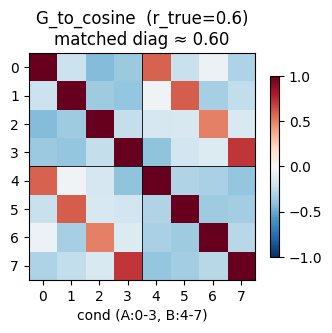

In [3]:
rng = np.random.default_rng(0)
Y, ci, cs, part, sess = simulate_correlation(r_true=0.6, common_sd=0.0, noise_sd=1.0, rng=rng)

G = xval_G(Y, ci, part, remove_run_mean=True)
C = pcm.G_to_cosine(G)

fig, ax = plt.subplots(figsize=(3.6, 3.2))
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(8)); ax.set_yticks(range(8))
ax.set_title(f'G_to_cosine  (r_true=0.6)\nmatched diag ≈ {cos_diag(G):.2f}')
ax.axhline(3.5, color='k', lw=.6); ax.axvline(3.5, color='k', lw=.6)
ax.set_xlabel('cond (A:0-3, B:4-7)')
fig.colorbar(im, ax=ax, shrink=.8); fig.tight_layout()
print('matched (diagonal) across-session cosine:', round(cos_diag(G), 3))

## Q1 — Run-mean removal & the crossnobis distance: within-session invariant, cross-session **not**

The classic result — *a pattern common to every condition cancels in every pairwise difference, so crossnobis distance
is invariant to it* — only holds when every condition appears in every run. Here each chord appears **only in its own
session's runs**, so across the session boundary the run mean is subtracted on one side of the contrast only, and it does
**not** cancel. Turn `common_sd` up: the within-session blocks stay pinned at 0 difference, the cross-session block moves.

max |ΔD| within-session (A-A, B-B): 0.0000   <- invariant to run-mean removal
max |ΔD| cross-session  (A-B)     : 0.2137   <- NOT invariant


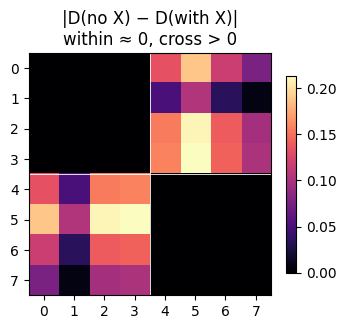

In [4]:
rng = np.random.default_rng(1)
Y, ci, cs, part, sess = simulate_correlation(r_true=0.6, common_sd=4.0, noise_sd=1.0, rng=rng)

D_noX = pcm.G_to_dist(xval_G(Y, ci, part, remove_run_mean=False))
D_X   = pcm.G_to_dist(xval_G(Y, ci, part, remove_run_mean=True))
dD    = np.abs(D_noX - D_X)

within = max(dD[:4, :4].max(), dD[4:, 4:].max())
cross  = dD[:4, 4:].max()
print(f'max |ΔD| within-session (A-A, B-B): {within:.4f}   <- invariant to run-mean removal')
print(f'max |ΔD| cross-session  (A-B)     : {cross:.4f}   <- NOT invariant')

fig, ax = plt.subplots(figsize=(3.6, 3.2))
im = ax.imshow(dD, cmap='magma')
ax.axhline(3.5, color='w', lw=.6); ax.axvline(3.5, color='w', lw=.6)
ax.set_title('|D(no X) − D(with X)|\nwithin ≈ 0, cross > 0')
ax.set_xticks(range(8)); ax.set_yticks(range(8))
fig.colorbar(im, ax=ax, shrink=.8); fig.tight_layout()

## Q2 — Run-mean removal & cosine: the common activation is the inflation knob

For **cosine** the run mean never cancels (no difference contrast), so it always matters. Growing the common activation
drives the raw matched cosine toward **1** regardless of the true correlation; removing the run mean (`X`) holds it at
`r_true`. This is the reason to keep `X=indicator(part_vec)` when you read a *correlation* off `G_to_cosine`.

no X   : [np.float64(0.601), np.float64(0.677), np.float64(0.795), np.float64(0.917), np.float64(0.975), np.float64(0.994)]
with X : [np.float64(0.603), np.float64(0.603), np.float64(0.603), np.float64(0.603), np.float64(0.603), np.float64(0.603)]


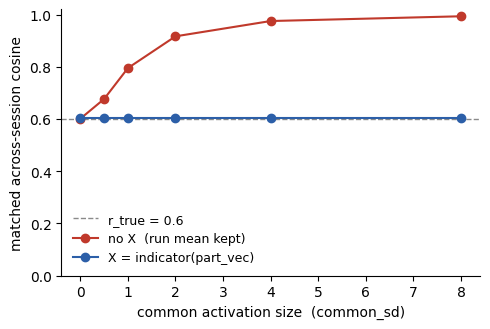

In [5]:
common_grid = [0, 0.5, 1, 2, 4, 8]
r_true, n_seed = 0.6, 30
no_X, with_X = [], []
for c in common_grid:
    a, b = [], []
    for seed in range(n_seed):
        r = np.random.default_rng(seed)
        Y, ci, cs, part, sess = simulate_correlation(r_true=r_true, common_sd=c, noise_sd=1.0, rng=r)
        a.append(cos_diag(xval_G(Y, ci, part, remove_run_mean=False)))
        b.append(cos_diag(xval_G(Y, ci, part, remove_run_mean=True)))
    no_X.append(np.mean(a)); with_X.append(np.mean(b))

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.axhline(r_true, color=GREY, ls='--', lw=1, label=f'r_true = {r_true}')
ax.plot(common_grid, no_X,   'o-', color=RED,  label='no X  (run mean kept)')
ax.plot(common_grid, with_X, 'o-', color=BLUE, label='X = indicator(part_vec)')
ax.set_xlabel('common activation size  (common_sd)')
ax.set_ylabel('matched across-session cosine')
ax.set_ylim(0, 1.02); ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9); fig.tight_layout()
print('no X   :', [round(v, 3) for v in no_X])
print('with X :', [round(v, 3) for v in with_X])

## Q3 — Voxel-mean centring is a *different* operation

`X=indicator(part_vec)` removes a common *pattern across conditions* (the run mean). `data - data.mean(axis=1)` removes
each pattern's *scalar mean across voxels*. They are not substitutes. Read the bars: **voxel-centred ≈ raw** (still
inflated) while **run-mean (X)** de-inflates to `r_true`. So voxel centring does *not* remove the common activation here —
only `X` does. (The common pattern is zero-voxel-mean, so voxel centring can't touch it; give the chords a non-zero mean
activity and the two operations diverge in yet another way.)

{'raw': np.float64(0.975), 'run-mean (X)': np.float64(0.593), 'voxel-centred': np.float64(0.976), 'both': np.float64(0.594)}


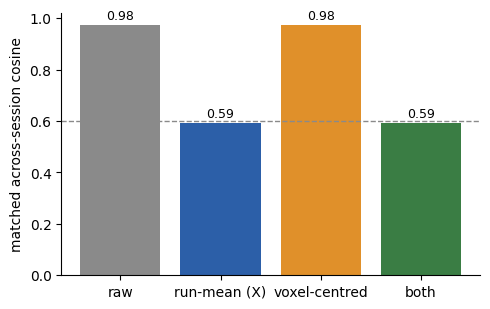

In [6]:
rng = np.random.default_rng(2)
Y, ci, cs, part, sess = simulate_correlation(r_true=0.6, common_sd=4.0, noise_sd=1.0, rng=rng)

combos = {'raw'              : dict(remove_run_mean=False, center_voxels=False),
          'run-mean (X)'     : dict(remove_run_mean=True,  center_voxels=False),
          'voxel-centred'    : dict(remove_run_mean=False, center_voxels=True),
          'both'             : dict(remove_run_mean=True,  center_voxels=True)}
vals = {k: cos_diag(xval_G(Y, ci, part, **kw)) for k, kw in combos.items()}

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(vals.keys(), vals.values(), color=[GREY, BLUE, '#e0902a', '#3a7d44'])
ax.axhline(0.6, color=GREY, ls='--', lw=1)
ax.set_ylabel('matched across-session cosine'); ax.set_ylim(0, 1.02)
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(vals.values()): ax.text(i, v + .02, f'{v:.2f}', ha='center', fontsize=9)
fig.tight_layout()
print({k: round(v, 3) for k, v in vals.items()})

## Q4 — Matched (diagonal) vs mismatched (off-diagonal) extraction

Same G, two different numbers. `correlation.py` reads `np.diagonal(C[:4, 4:])` — the **matched** chord A↔B similarity,
≈ `r_true`. `geometry`'s `split_trained` reads the off-diagonal (`np.tri(4, k=-1)`) — **different** chords across sessions,
≈ 0. These are not comparable measures, which is why the two scripts disagree.

In [7]:
rng = np.random.default_rng(3)
Y, ci, cs, part, sess = simulate_correlation(r_true=0.6, common_sd=2.0, noise_sd=1.0, rng=rng)
G = xval_G(Y, ci, part, remove_run_mean=True)
print(f'matched   diagonal   (correlation.py)  : {cos_diag(G):+.3f}   ~ r_true')
print(f'mismatched off-diag  (split_trained)   : {cos_offdiag(G):+.3f}   ~ 0')

matched   diagonal   (correlation.py)  : +0.573   ~ r_true
mismatched off-diag  (split_trained)   : -0.190   ~ 0


## Q5 — The PCM correlation model recovers `r_true` and agrees with the run-mean-removed matched cosine

`fit_correlation` (the `CorrelationModel` MLE, with `fixed_effect='block'`) should land on `r_true`, and track the
cross-validated matched cosine as noise grows. If these two ever diverge in the real pipeline, suspect an inconsistency
in what mean was removed.

MLE  : [np.float64(0.603), np.float64(0.601), np.float64(0.592), np.float64(0.563)]
xcos : [np.float64(0.602), np.float64(0.6), np.float64(0.595), np.float64(0.562)]


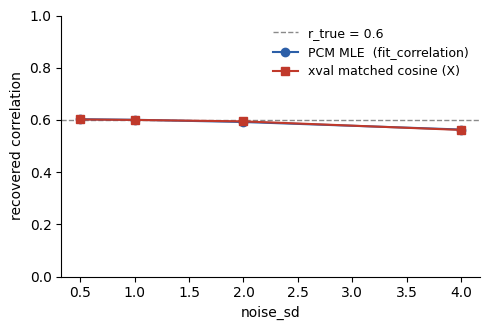

In [8]:
r_true = 0.6
noise_grid = [0.5, 1.0, 2.0, 4.0]
mle, xcos = [], []
for ns in noise_grid:
    m, x = [], []
    for seed in range(15):
        r = np.random.default_rng(seed)
        Y, ci, cs, part, sess = simulate_correlation(r_true=r_true, common_sd=2.0, noise_sd=ns, rng=r)
        ds = pcm.Dataset(Y, obs_descriptors={'cond_vec': cs, 'part_vec': part})
        with contextlib.redirect_stdout(open(os.devnull, 'w')):   # hush PCM's per-fit chatter
            r_indiv, _, _ = fit_correlation(ds, Mflex)
        m.append(float(r_indiv[0]))
        x.append(cos_diag(xval_G(Y, ci, part, remove_run_mean=True)))
    mle.append(np.mean(m)); xcos.append(np.mean(x))

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.axhline(r_true, color=GREY, ls='--', lw=1, label=f'r_true = {r_true}')
ax.plot(noise_grid, mle,  'o-', color=BLUE, label='PCM MLE  (fit_correlation)')
ax.plot(noise_grid, xcos, 's-', color=RED,  label='xval matched cosine (X)')
ax.set_xlabel('noise_sd'); ax.set_ylabel('recovered correlation')
ax.set_ylim(0, 1.0); ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9); fig.tight_layout()
print('MLE  :', [round(v, 3) for v in mle])
print('xcos :', [round(v, 3) for v in xcos])